## Time to get your hands dirty! Supernova distances and redshifts (part 1)

Measuring the cosmological relationship between distance and redshift is at the heart of the entire field of cosmology and allowed, among other things, the discovery of dark energy! At high redshifts, this is done with Type Ia Supernova which are standard (or better, standardizable) candles.

This is a [Nobel prize](https://www.nobelprize.org/prizes/physics/2011/riess/facts/) plot by [Riess et al](https://iopscience.iop.org/article/10.1086/300499)


<img src="/Users/albertodufour/code/astrostatistics_bicocca_2025/imgs/nobel.png" alt="Nobel Prize Image" width="1000"/>


Let's recall the definition of magnitude and the distance modulus (ah! the astronomers...)

$$
\mu = m-M =  5 \log_{10}\left(\frac{d_L}{\rm pc}\right) - 5
$$

Here is the Hubble diagram for Type Ia supernovae (which are standard candels). The lines show the predictions for cosmologies with varying amounts of Ωm and ΩΛ. The observed points all lie above the line for a universe with zero Λ. The lower panel, with the slope caused by the inverse square law taken out, shows the difference between the predictions more clearly and shows why a model with ΩΛ > 0 is favored.

These are some (synthetic but realistic; see textbook) supernova data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_11253/179283927.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

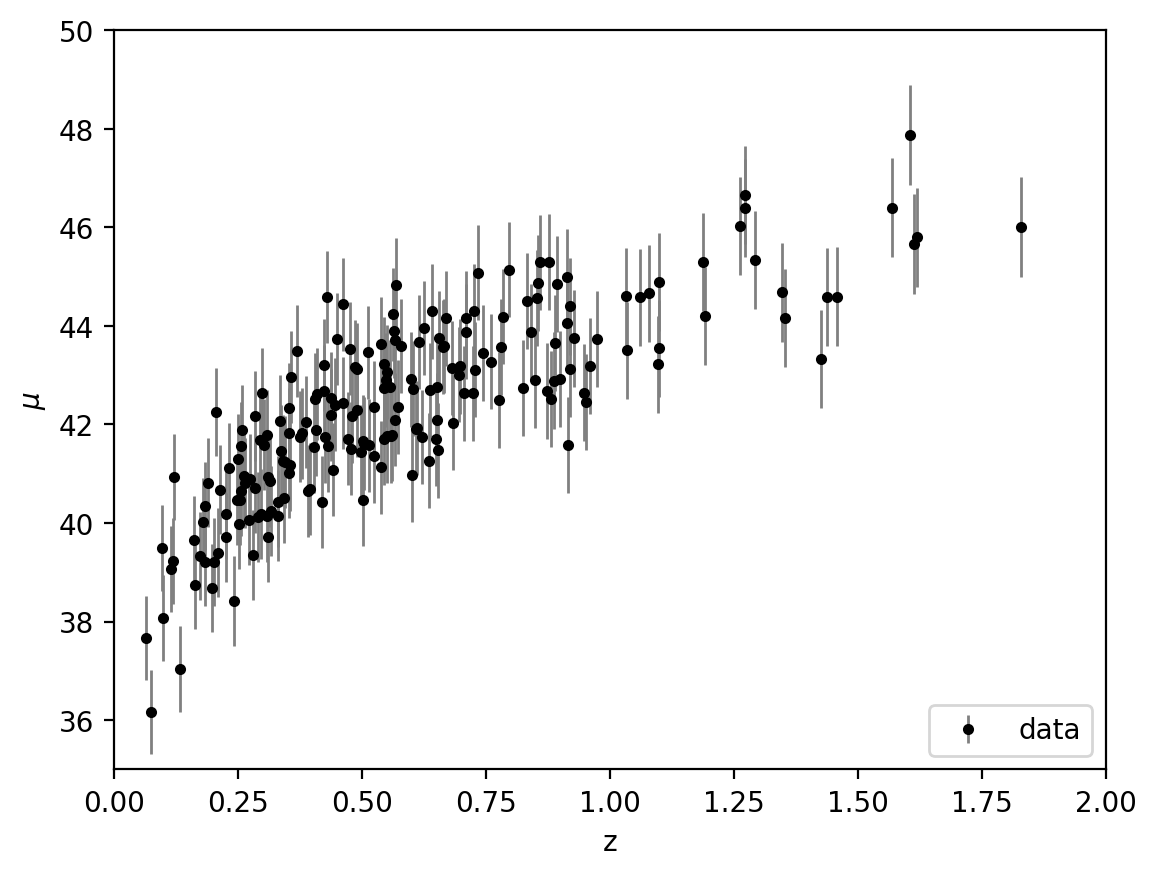

In [3]:
from astroML.datasets import generate_mu_z
NPOINTS = 200
z_sample, mu_sample, dmu = generate_mu_z(NPOINTS, random_state=120)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

####  Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_11253/4227262838.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_11253/4227262838.py:5: RankWarning: Polyfit may be poorly conditioned
  mu_fit = np.poly1d(np.polyfit(z_sample,mu_sample,deg, w=1/dmu))
/var/folders/p0/lxv02_717plcjl85mgd2gz940000gn/T/ipykernel_11253/4227262838.py:5: RankWarning: Polyfit may be poorly conditioned
  mu_fit = np.poly1d(np.polyfit(z_sample,mu_sample,deg, w=1/dmu))


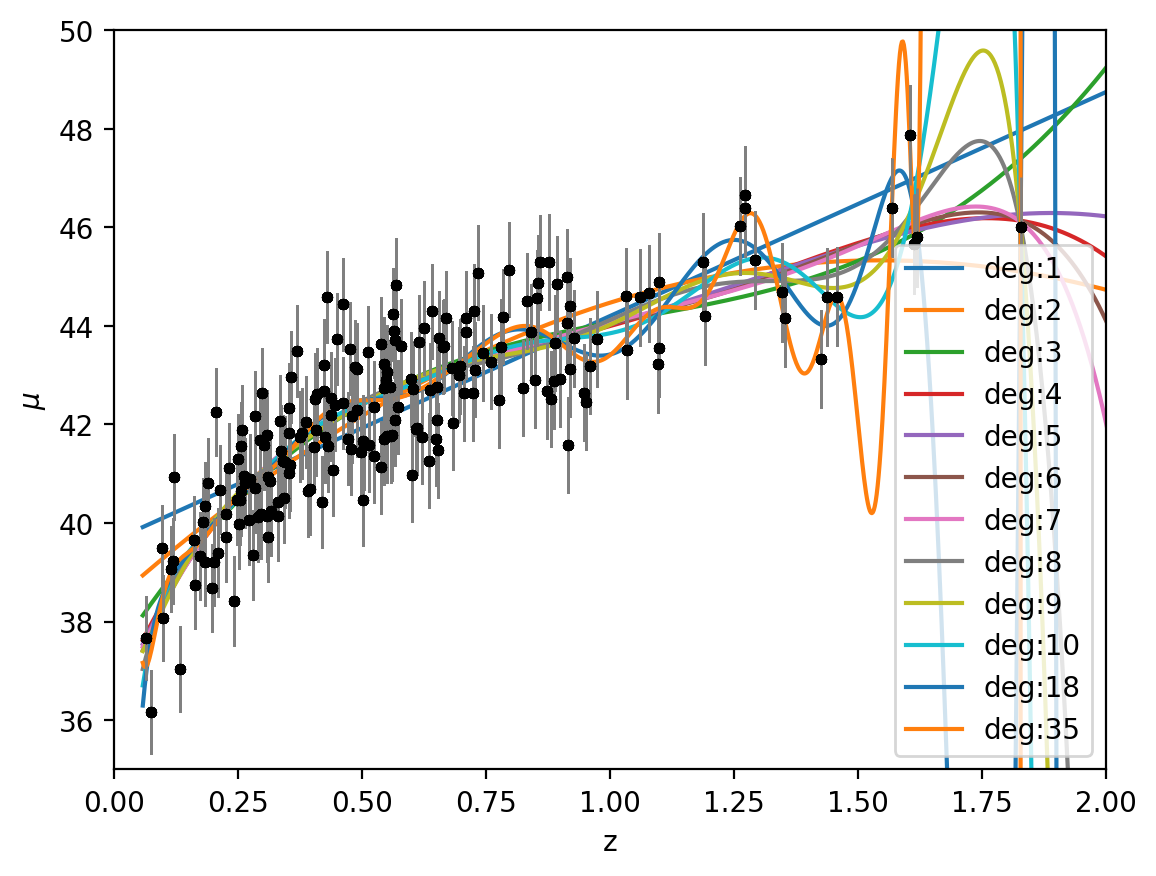

In [4]:
#---------- POLYNOMIAL FITTING ---------------
# can be easily be done with numpy
for deg in [1,2,3,4,5,6,7, 8, 9,10, 18, 35]:
    #polyfit expects weigths as the inverse of uncertainty
    mu_fit = np.poly1d(np.polyfit(z_sample,mu_sample,deg, w=1/dmu)) 

    xgrid = np.linspace(np.min(z_sample)*0.9, np.max(z_sample)*1.1, 1000)

    plt.plot(xgrid, mu_fit(xgrid), label=f'deg:{deg}')
    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)
    plt.xlabel("z")
    plt.ylabel("$\mu$")
    plt.legend(loc='lower right')
    plt.xlim(0,2)
    plt.ylim(35,50)


Linear is clearly underfitting\
Deg 4,5 probably overfitting

In [5]:
degrees_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15]

In [14]:
#---------- CROSS VALIDATION ----------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
# sklearn format
X = z_sample[:, np.newaxis]
y = mu_sample

param_grid = {
    # Key: parameter name in the pipeline
    # Value: list of degrees to evaluate
    'poly_features__degree': degrees_list
}

# sklearn does not have a polynomial regressor such as astroML.linear_model.PolynomialRegression
# input data features must be first transformed into polynomial features using sklearn.preprocessing.PolynomialFeatures
# polynomial features can then just be fitted with linear regression

#using Pipeline to pack PolynomialFeatures and LinearRegression
def PolynomialRegressor():
        return Pipeline([
                # Convert input features to polynomial features
                # This step creates new features by taking all polynomial combinations
                ('poly_features', PolynomialFeatures()),
                
                # Standard linear regression on the polynomial features
                ('linear_regression', LinearRegression())
        ])


#------------- GRID SEARCH -----------
cv = int(NPOINTS/10)
grid_search = GridSearchCV(
    # Estimator: the model pipeline to evaluate
    estimator=PolynomialRegressor(), param_grid=param_grid, cv=cv,
    scoring='neg_mean_squared_error', return_train_score=True 
)

#linear regression expects 1/var as weights
weights = 1 / dmu**2
grid_search.fit(X, y, linear_regression__sample_weight=weights)

best_degree = grid_search.best_params_['poly_features__degree']

means = - grid_search.cv_results_['mean_train_score']
rms = grid_search.cv_results_['std_train_score']

print(best_degree)


4


In [12]:
results = grid_search.cv_results_

# Degrees tested in the grid
degrees = results['param_poly_features__degree'].data.astype(int)

# Convert neg-MSE to RMSE
train_rmse = np.sqrt(-results['mean_train_score'])
val_rmse   = np.sqrt(-results['mean_test_score'])

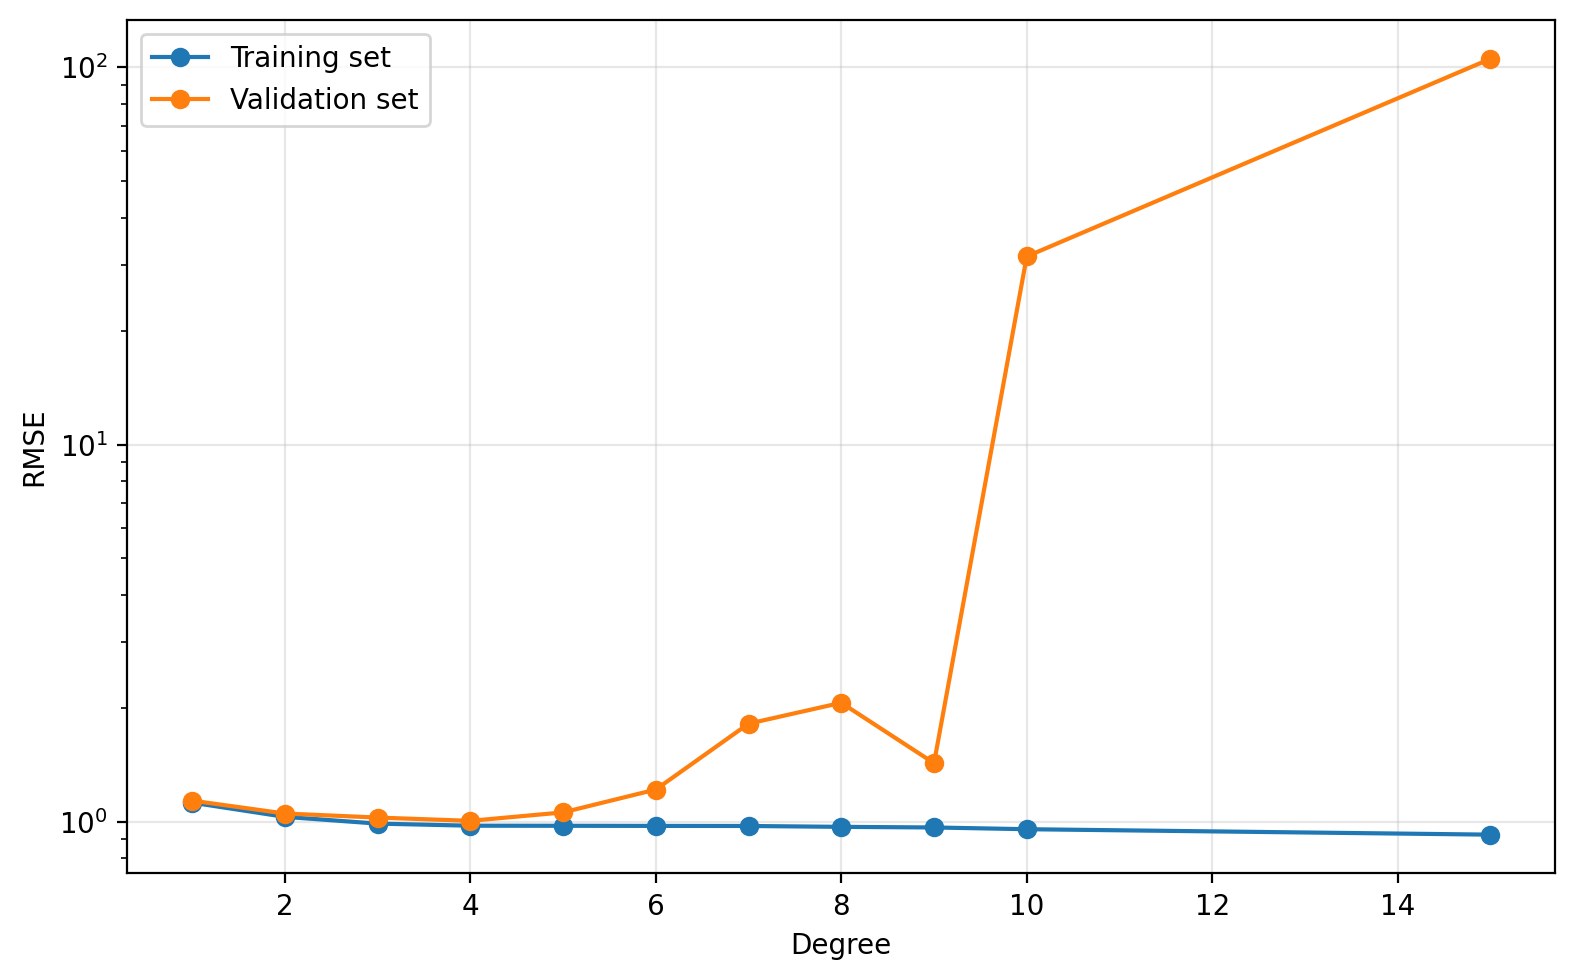

In [13]:
plt.figure(figsize=(8,5))
plt.plot(degrees, train_rmse, 'o-', label='Training set')
plt.plot(degrees, val_rmse, 'o-', label='Validation set')

plt.xlabel("Degree")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.yscale("log")
plt.show()


#### If you have time (or later at home...)

- Repeat with Basis Function Regression and Kernel Regression
- Explore what happens when you change the number of datapoints and plot the resulting learning curves.


In [9]:
# basis function regressione and kernel regression are astroML methods:
# using GridSearchCV would probably too complicated
# (I would have to create some structure that uses astroML.linear_model.BasisFunctionRegression and NadarayaWatson
# that is compatible with scikit)

#ALTERNATIVE: sklearn.model_selection.train_test_split (not as good as K-fold CV of course)

### **I DID NOT USE THE ERRORS!!!**